   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

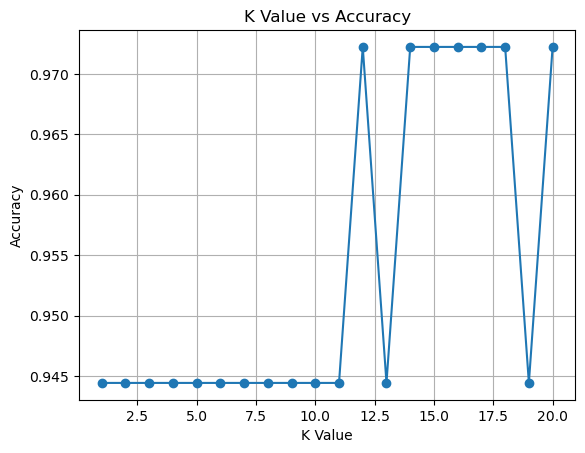


Final Accuracy: 0.9722222222222222


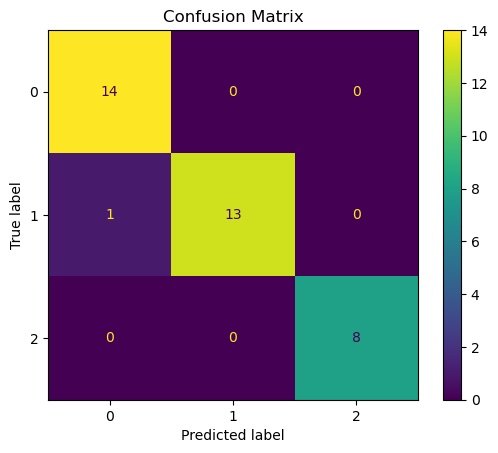

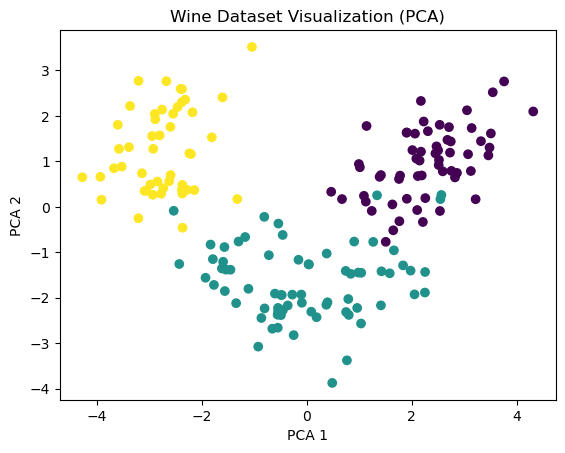

Predicted Class: class_0


In [6]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

#load dataset
wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print(df.head())

print("\nMissing values:\n", df.isnull().sum())

#Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#choosing best K

k_values = []
accuracies = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred_k = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred_k)

    k_values.append(k)
    accuracies.append(acc)

    print("K =", k, "Accuracy =", acc)

best_k = k_values[np.argmax(accuracies)]

print("\nBest K Value:", best_k)

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.grid(True)

plt.show()

#model training
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# model evaluation
print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Wine Dataset Visualization (PCA)")

plt.show()

#external data
sample = [[13.0, 2.0, 2.5, 15.0, 100.0, 2.5, 2.0, 0.3, 1.5, 5.0, 1.0, 3.0, 1000.0]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted Class:", wine.target_names[prediction[0]])